# Task
Perform an in-depth analysis of the "chatgpt_reviews.csv" dataset to understand user feedback on ChatGPT. This includes data loading and cleaning, analyzing the distribution of ratings and sentiment, identifying temporal trends in ratings and sentiment, extracting common keywords from all reviews, and specifically from negative reviews to identify user issues. Finally, summarize insights and provide actionable recommendations for improving ChatGPT based on the analysis.

## Load Data and Initial Exploration



Load the 'chatgpt_reviews.csv' dataset into a pandas DataFrame. Inspect the dataset's structure, column types using `.info()`, display the first few rows with `.head()`, and check for any missing values using `.isnull().sum()` to ensure data quality. Libraries for data manipulation (pandas) and visualization (matplotlib, seaborn) should be imported in a single cell.


**Reasoning**:
 import the necessary libraries, then load the dataset, display its first few rows, show its structure and data types, and check for missing values to ensure data quality, all in a single code block as per the instructions.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('chatgpt_reviews.csv')

print('First 5 rows of the dataset:')
# Display the first 5 rows
print(df.head())

print('\nConcise summary of the DataFrame:')
# Print a concise summary of the DataFrame
df.info()

print('\nNumber of missing values in each column:')
# Check for missing values
print(df.isnull().sum())

First 5 rows of the dataset:
                              Review Id  \
0  6fb93778-651a-4ad1-b5ed-67dd0bd35aac   
1  81caeefd-3a28-4601-a898-72897ac906f5   
2  452af49e-1d8b-4b68-b1ac-a94c64cb1dd5   
3  372a4096-ee6a-4b94-b046-cef0b646c965   
4  b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da   

                                              Review  Ratings  \
0                                               good        5   
1                                               good        5   
2                                           nice app        5   
3                                           nice, ig        5   
4  this is a great app, the bot is so accurate to...        5   

           Review Date  
0  2024-08-23 19:30:05  
1  2024-08-23 19:28:18  
2  2024-08-23 19:22:59  
3  2024-08-23 19:20:50  
4  2024-08-23 19:20:39  

Concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null

## Data Cleaning

### Subtask:
Handle missing values in the 'Review' column by filling them with empty strings. Convert the 'Review Date' column to datetime objects, coercing errors to `NaT`.


**Reasoning**:
handle missing values in the 'Review' column by filling them with empty strings and convert the 'Review Date' column to datetime objects, coercing errors to NaT, as specified in the subtask.



In [2]:
print('Before cleaning:')
print(df[['Review', 'Review Date']].isnull().sum())

# Fill missing values in 'Review' column with empty strings
df['Review'] = df['Review'].fillna('')

# Convert 'Review Date' to datetime objects, coercing errors
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')

print('\nAfter cleaning:')
print(df[['Review', 'Review Date']].isnull().sum())

Before cleaning:
Review         6
Review Date    0
dtype: int64

After cleaning:
Review         0
Review Date    0
dtype: int64


## Analyze Ratings Distribution

### Subtask:
Calculate and visualize the distribution of star ratings (0-5 stars). Use `value_counts()` to get the frequency and percentage of each rating, and create a bar chart to graphically represent the distribution of ratings. The chart should include a legend and appropriate labels.


**Reasoning**:
I will calculate the frequency and percentage distribution of the 'Ratings' column, print them, and then create a bar chart to visualize this distribution as per the instructions.



--- Ratings Distribution ---

Frequency of each rating:
Ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64

Percentage of each rating:
Ratings
1     6.142014
2     1.715575
3     4.146355
4    11.638972
5    76.357084
Name: proportion, dtype: float64


/tmp/ipython-input-542/398362381.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


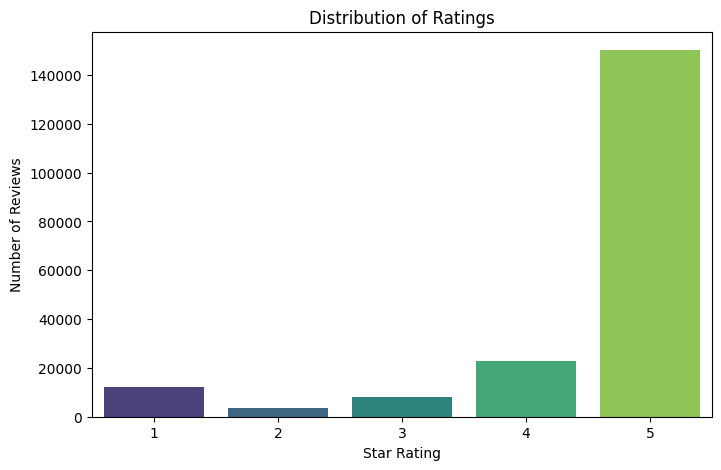

In [3]:
print('--- Ratings Distribution ---')

# Calculate frequency of each rating
rating_counts = df['Ratings'].value_counts().sort_index()
print('\nFrequency of each rating:')
print(rating_counts)

# Calculate percentage distribution of each rating
rating_percentages = (df['Ratings'].value_counts(normalize=True) * 100).sort_index()
print('\nPercentage of each rating:')
print(rating_percentages)

# Create a bar plot for the distribution of ratings
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` regarding the `palette` argument in `sns.barplot`. To resolve this, I will modify the `sns.barplot` call by explicitly setting the `x` variable as `hue` and `legend=False` as suggested by the warning.



--- Ratings Distribution ---

Frequency of each rating:
Ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64

Percentage of each rating:
Ratings
1     6.142014
2     1.715575
3     4.146355
4    11.638972
5    76.357084
Name: proportion, dtype: float64


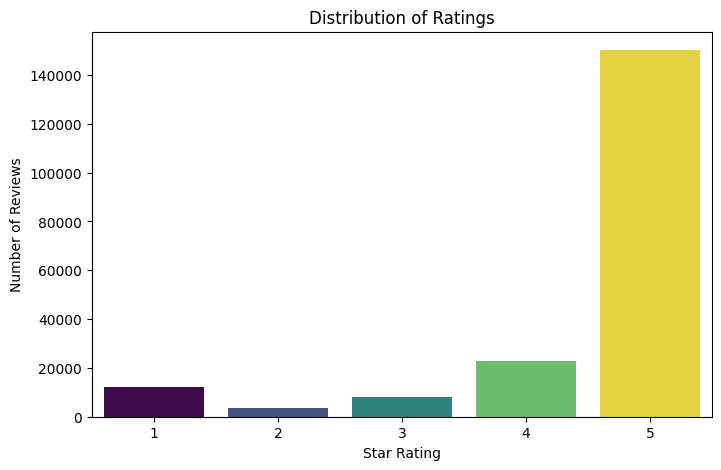

In [4]:
print('--- Ratings Distribution ---')

# Calculate frequency of each rating
rating_counts = df['Ratings'].value_counts().sort_index()
print('\nFrequency of each rating:')
print(rating_counts)

# Calculate percentage distribution of each rating
rating_percentages = (df['Ratings'].value_counts(normalize=True) * 100).sort_index()
print('\nPercentage of each rating:')
print(rating_percentages)

# Create a bar plot for the distribution of ratings
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## Perform Sentiment Analysis

### Subtask:
Apply sentiment analysis to the 'Review' text using TextBlob. Define a function to calculate sentiment polarity for each review and create a new 'Polarity' column. Categorize each review as 'positive', 'neutral', or 'negative' based on polarity and store this in a 'Sentiment' column. The TextBlob library should be imported.


**Reasoning**:
I will import TextBlob, define functions to calculate polarity and categorize sentiment, apply these functions to create 'Polarity' and 'Sentiment' columns, and then display the head of the DataFrame to verify the changes, as per the instructions.



In [5]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment_polarity(text):
    return TextBlob(text).sentiment.polarity

# Apply the function to create 'Polarity' column
df['Polarity'] = df['Review'].apply(get_sentiment_polarity)

# Function to categorize sentiment based on polarity
def get_sentiment_category(polarity):
    if polarity > 0:
        return 'positive'
    elif polarity == 0:
        return 'neutral'
    else:
        return 'negative'

# Apply the function to create 'Sentiment' column
df['Sentiment'] = df['Polarity'].apply(get_sentiment_category)

# Display the first few rows with new columns
print('DataFrame with new Polarity and Sentiment columns:')
print(df[['Review', 'Polarity', 'Sentiment']].head())

DataFrame with new Polarity and Sentiment columns:
                                              Review  Polarity Sentiment
0                                               good    0.7000  positive
1                                               good    0.7000  positive
2                                           nice app    0.6000  positive
3                                           nice, ig    0.6000  positive
4  this is a great app, the bot is so accurate to...    0.4125  positive


## Visualize Sentiment Distribution

### Subtask:
Calculate the count of each sentiment category ('positive', 'neutral', 'negative') and visualize their distribution using a bar chart. The chart should include a legend and appropriate labels.


**Reasoning**:
I will calculate the frequency of each sentiment category and then visualize this distribution using a bar chart with appropriate labels and title, as instructed.



--- Sentiment Distribution ---

Frequency of each sentiment category:
Sentiment
positive    150122
neutral      38450
negative      8155
Name: count, dtype: int64

Percentage of each sentiment category:
Sentiment
positive    76.309810
neutral     19.544851
negative     4.145338
Name: proportion, dtype: float64


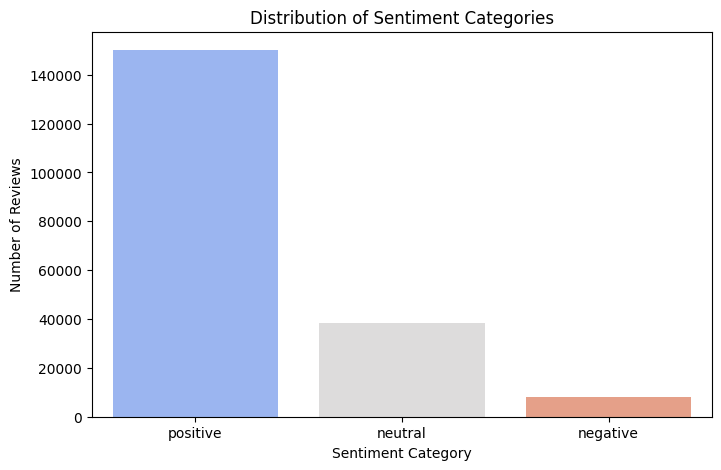

In [6]:
print('--- Sentiment Distribution ---')

# Calculate frequency of each sentiment category
sentiment_counts = df['Sentiment'].value_counts()
print('\nFrequency of each sentiment category:')
print(sentiment_counts)

# Calculate percentage distribution of each sentiment category
sentiment_percentages = (df['Sentiment'].value_counts(normalize=True) * 100)
print('\nPercentage of each sentiment category:')
print(sentiment_percentages)

# Create a bar plot for the distribution of sentiment categories
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, palette='coolwarm', legend=False)
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## Analyze Temporal Trends in Ratings and Sentiment

### Subtask:
Extract the year and month from the 'Review Date' to create 'Review_Year' and 'Review_Month' columns. Group the data by these columns to calculate the monthly average ratings and average sentiment polarity. Create a 'Time_Period' column from year and month. Plot line charts to visualize the trends of average ratings and average sentiment polarity over time. Each chart should have appropriate titles and axis labels, and include a legend.


**Reasoning**:
I will extract the year and month from the 'Review Date' column, create a 'Time_Period' column, calculate the monthly average ratings and sentiment polarity, and then plot these trends using line charts with appropriate labels and titles, as instructed.



Monthly average ratings and polarity (first 5 rows):
  Time_Period  Avg_Rating  Avg_Polarity
0  2023-07-01    4.439454      0.369545
1  2023-08-01    4.327746      0.385239
2  2023-09-01    4.494534      0.424308
3  2023-10-01    4.525755      0.433077
4  2023-11-01    4.523913      0.428241


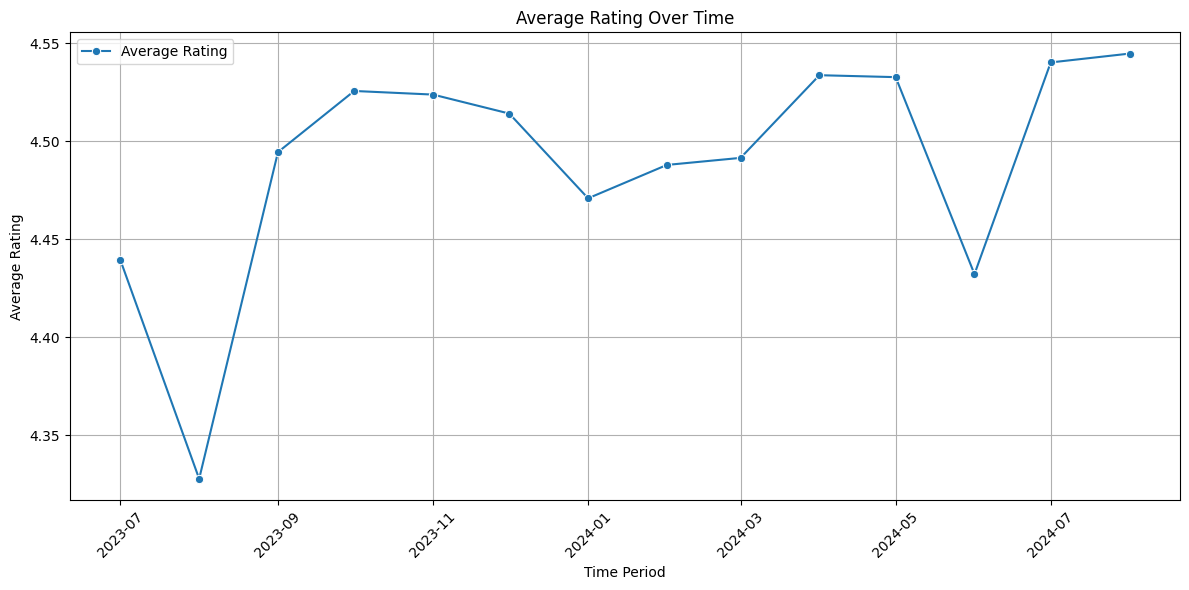

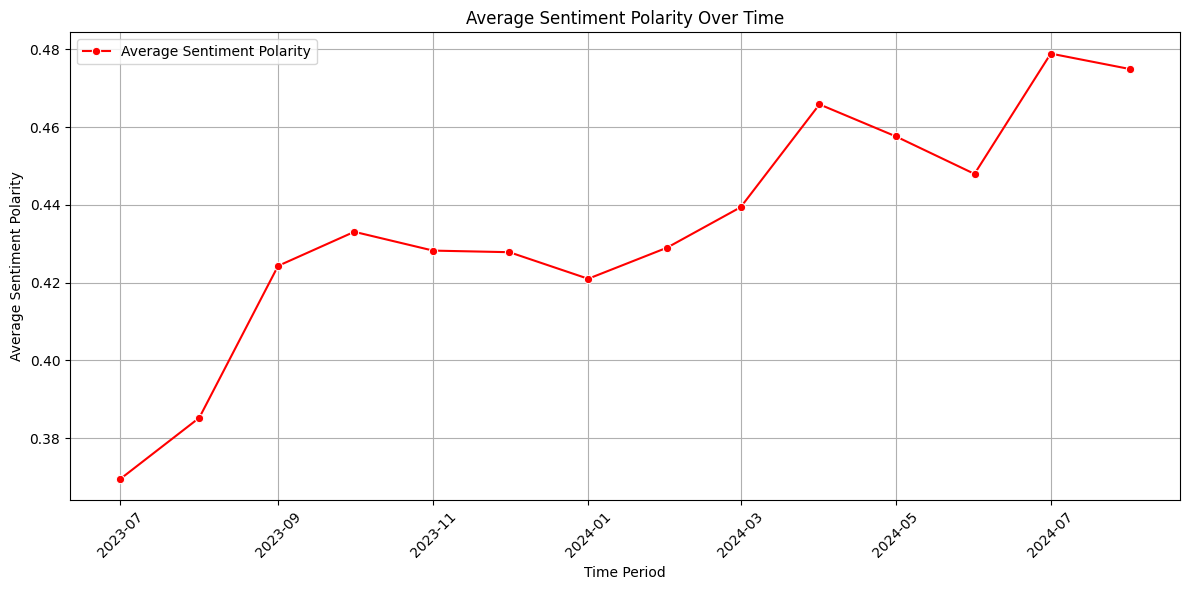

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract year and month from 'Review Date'
df['Review_Year'] = df['Review Date'].dt.year
df['Review_Month'] = df['Review Date'].dt.month

# Create 'Time_Period' column (YYYY-MM format)
df['Time_Period'] = df['Review Date'].dt.to_period('M').astype(str)

# Group by 'Time_Period' and calculate monthly average ratings and polarity
trend_data = df.groupby('Time_Period').agg(
    Avg_Rating=('Ratings', 'mean'),
    Avg_Polarity=('Polarity', 'mean')
).reset_index()

# Convert 'Time_Period' back to datetime for proper plotting order
trend_data['Time_Period'] = pd.to_datetime(trend_data['Time_Period'])

# Sort by Time_Period to ensure correct chronological plotting
trend_data = trend_data.sort_values(by='Time_Period')

print('Monthly average ratings and polarity (first 5 rows):')
print(trend_data.head())

# Plot Average Rating Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Time_Period', y='Avg_Rating', data=trend_data, marker='o', label='Average Rating')
plt.title('Average Rating Over Time')
plt.xlabel('Time Period')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Average Sentiment Polarity Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Time_Period', y='Avg_Polarity', data=trend_data, marker='o', color='red', label='Average Sentiment Polarity')
plt.title('Average Sentiment Polarity Over Time')
plt.xlabel('Time Period')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Text Preprocessing for Keyword Extraction

### Subtask:
Import necessary NLTK libraries (stopwords, wordnet) and define a text preprocessing function. This function should convert text to lowercase, remove punctuation and numbers, tokenize, remove stopwords, and lemmatize words. Apply this function to the 'Review' column to create a 'Processed_Review' column.


In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download necessary NLTK data (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    WordNetLemmatizer().lemmatize('test')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and load stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define the preprocessing function
def preprocess_text(text):
    if not isinstance(text, str): # Ensure text is a string
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join back into a string
    return ' '.join(words)

# Apply the preprocessing function to create 'Processed_Review' column
df['Processed_Review'] = df['Review'].apply(preprocess_text)

# Display the first few rows of 'Review' and 'Processed_Review'
print('Original and Processed Reviews (first 5 rows):')
print(df[['Review', 'Processed_Review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original and Processed Reviews (first 5 rows):
                                              Review  \
0                                               good   
1                                               good   
2                                           nice app   
3                                           nice, ig   
4  this is a great app, the bot is so accurate to...   

                                    Processed_Review  
0                                               good  
1                                               good  
2                                           nice app  
3                                            nice ig  
4  great app bot accurate anything give tip gamin...  


## Extract Common Keywords from All Reviews




In [24]:
from collections import Counter

print('--- Common Keywords from All Reviews ---')

# Combine all processed reviews into a single string
all_reviews_text = ' '.join(df['Processed_Review'].dropna())

# Split the string into individual words
all_words = all_reviews_text.split()

# Use Counter to find the 20 most frequently occurring words
common_words = Counter(all_words).most_common(20)

print('\nTop 20 most common keywords from all reviews:')
for word, count in common_words:
    print(f"'{word}': {count}")

--- Common Keywords from All Reviews ---

Top 20 most common keywords from all reviews:
'app': 50650
'good': 39704
'best': 18450
'nice': 13884
'ai': 12127
'great': 11989
'helpful': 11669
'chatgpt': 10255
'like': 9090
'amazing': 8741
'love': 8700
'help': 7924
'answer': 7855
'useful': 7634
'use': 7465
'really': 7382
'chat': 6539
'excellent': 6203
'work': 5963
'give': 5561


**Reasoning**:
The previous code failed with a `TypeError` because `top_scores` contained `numpy.matrix` objects instead of scalar floats, preventing proper formatting. I will fix this by converting the `avg_tfidf_scores` matrix to a flattened NumPy array before extracting scores and indices, ensuring scalar values are used.



--- TF-IDF Keyword Extraction for All Reviews ---

Top 10 keywords from all reviews (TF-IDF based):
'good': 0.1233
'app': 0.0709
'nice': 0.0508
'best': 0.0445
'great': 0.0318
'helpful': 0.0318
'amazing': 0.0253
'excellent': 0.0241
'love': 0.0219
'useful': 0.0205


/tmp/ipython-input-542/1016938605.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TF-IDF Score', y='Keyword', data=top_words_df, palette='magma')


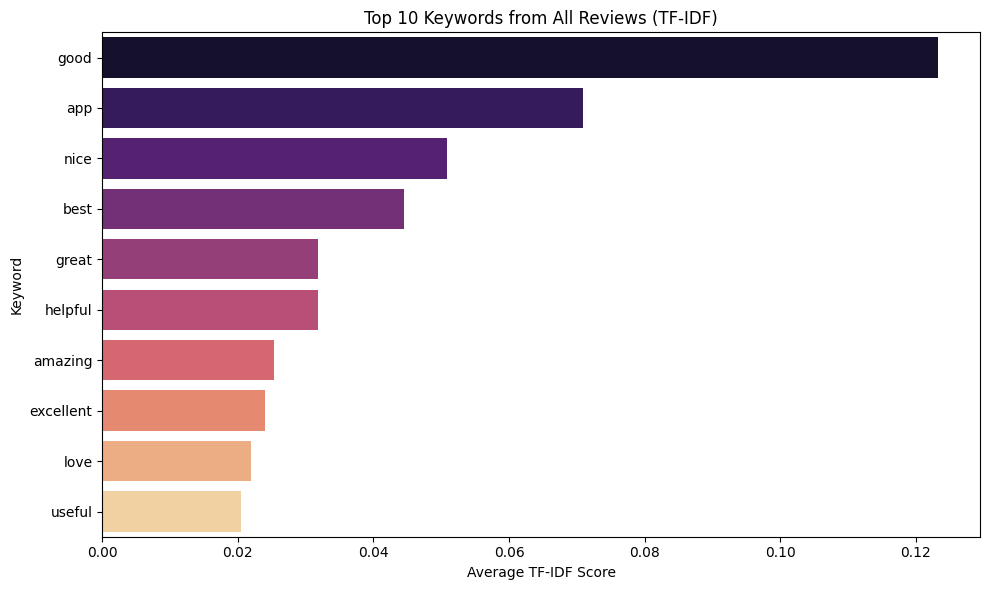

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('--- TF-IDF Keyword Extraction for All Reviews ---')

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to top 5000 features for efficiency

# Fit and transform the processed reviews
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Processed_Review'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate average TF-IDF scores for each word
avg_tfidf_scores_matrix = tfidf_matrix.mean(axis=0)

# Convert the 1xN matrix to a 1D numpy array for easier indexing and sorting
avg_tfidf_scores_array = np.asarray(avg_tfidf_scores_matrix).flatten()

# Get the top N words by TF-IDF score
top_n = 10
top_word_indices = avg_tfidf_scores_array.argsort()[::-1][:top_n]

# Get the top words and their scores using these indices
top_words = [feature_names[i] for i in top_word_indices]
top_scores = [avg_tfidf_scores_array[i] for i in top_word_indices]

print(f'\nTop {top_n} keywords from all reviews (TF-IDF based):')
for word, score in zip(top_words, top_scores):
    print(f"'{word}': {score:.4f}")

# Create a DataFrame for visualization
top_words_df = pd.DataFrame({'Keyword': top_words, 'TF-IDF Score': top_scores})

# Plotting the top N keywords
plt.figure(figsize=(10, 6))
sns.barplot(x='TF-IDF Score', y='Keyword', data=top_words_df, palette='magma')
plt.title(f'Top {top_n} Keywords from All Reviews (TF-IDF)')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()